# Home Credit Default Risk -- Exploratory Data Analysis

This notebook is the source of truth for the EDA shown in the Streamlit
app's "EDA" page (`app/pages/1_EDA.py`) -- the same `src/data` modules
power both, so the notebook and the app can never drift out of sync.

Convert to `.ipynb` with: `jupytext --to notebook eda.py`
(or just run this file directly with `python notebooks/eda.py`)

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import pandas as pd

from src.data.loader import load_full_dataset
from src.data.preprocessor import engineer_features

pd.set_option("display.max_columns", 60)

## 1. Load data

Requires the real dataset at `data/raw/application_train.csv` (see
`data/README.md`). `USE_SYNTHETIC_FALLBACK=true` can be set as an env
var to run this notebook against the synthetic dev fixture instead, for
quick iteration without the full download.

In [2]:
df, source = load_full_dataset()
df = engineer_features(df)
print(f"Data source: {source}")
print(f"Shape: {df.shape}")
df.head()

2026-09-05 13:23:41 | WARNING  | credit_risk.loader | application_train.csv not found in data/raw/. USE_SYNTHETIC_FALLBACK=true, so falling back to synthetic data for this run.


2026-09-05 13:23:41 | INFO     | credit_risk.synthetic | Generated synthetic application table: 15000 rows, base default rate 8.65%


2026-09-05 13:23:41 | INFO     | credit_risk.synthetic | Generated synthetic bureau table: 36701 rows


2026-09-05 13:23:43 | INFO     | credit_risk.loader | Loaded full dataset: 15000 rows, 46 columns, source=synthetic


Data source: synthetic
Shape: (15000, 59)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,REGION_RATING_CLIENT,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,REGION_POPULATION_RELATIVE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,DEF_30_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,TARGET,BUREAU_CREDIT_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_AMT_CREDIT_SUM_TOTAL,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_OVERDUE_TOTAL,BUREAU_MAX_DAYS_OVERDUE,BUREAU_DAYS_CREDIT_MEAN,BUREAU_ACTIVE_RATIO,BUREAU_HAS_OVERDUE,AGE_YEARS,EMPLOYED_YEARS,EMPLOYED_TO_AGE_RATIO,CREDIT_TO_INCOME_RATIO,ANNUITY_TO_INCOME_RATIO,CREDIT_TO_GOODS_RATIO,INCOME_PER_FAMILY_MEMBER,ANNUITY_TO_CREDIT_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_MAX,EXT_SOURCE_MIN,EXT_SOURCE_MISSING_COUNT,BUREAU_OVERDUE_PER_CREDIT
0,100001,Cash loans,F,N,Y,1,3,Working,Higher education,Single / not married,House / apartment,Security staff,Self-employed,3,86900.0,339300.0,18310.0,326900.0,-18197,-549.0,-10068,-6633,NaN,0.609193,0.454419,NaN,0.0216,1,1,0,0,0,0,0,0,1,0,1.0,1.0,4955.046290,4955.046290,0.0,0.0,-2894.0,1.0,0.0,49.820671,1.503080,0.030170,3.904488,0.210702,1.037932,28966.666667,0.053964,0.531806,0.609193,0.454419,1,0.0
1,100002,Cash loans,M,N,N,2,4,Working,Secondary / secondary special,Married,House / apartment,Medicine staff,Medicine,2,82900.0,229400.0,8790.0,211000.0,-16815,-7790.0,-8059,-3378,NaN,NaN,0.590022,0.286744,0.0212,1,1,0,1,0,0,0,0,1,0,2.0,0.0,114094.766233,57047.383117,0.0,0.0,-1502.0,0.0,0.0,46.036961,21.327858,0.463277,2.767189,0.106031,1.087204,20725.000000,0.038317,0.438383,0.590022,0.286744,1,0.0
2,100003,Cash loans,M,N,Y,1,2,Working,Secondary / secondary special,Married,House / apartment,Medicine staff,Business Entity Type 3,2,119300.0,757700.0,28690.0,690000.0,-13464,-1001.0,-11399,-3618,NaN,0.503224,0.631363,0.845664,0.0420,1,1,0,0,0,0,0,0,1,0,1.0,1.0,25349.934504,25349.934504,0.0,0.0,-835.0,1.0,0.0,36.862423,2.740589,0.074346,6.351215,0.240486,1.098116,59650.000000,0.037865,0.660084,0.845664,0.503224,0,0.0
3,100004,Cash loans,F,Y,Y,1,2,Working,Secondary / secondary special,Single / not married,House / apartment,High skill tech staff,Trade: type 7,2,140600.0,240300.0,12860.0,233500.0,-14030,-6648.0,-9597,-4183,10.0,NaN,1.000000,0.424000,0.0418,1,1,0,0,0,0,0,0,2,0,6.0,3.0,150210.979287,25035.163215,0.0,0.0,-798.0,0.5,0.0,38.412047,18.201232,0.473842,1.709104,0.091465,1.029122,70300.000000,0.053516,0.712000,1.000000,0.424000,1,0.0
4,100005,Cash loans,F,Y,Y,1,3,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,Trade: type 7,3,56000.0,104800.0,9230.0,104000.0,-23706,-1248.0,-14621,-5152,15.0,0.400418,0.403891,NaN,0.0445,1,0,0,0,0,0,0,0,1,0,1.0,0.0,58179.590609,58179.590609,0.0,0.0,-736.0,0.0,0.0,64.903491,3.416838,0.052645,1.871429,0.164821,1.007692,18666.666667,0.088073,0.402155,0.403891,0.400418,1,0.0


## 2. Dataset summary & data quality

In [3]:
print("Base default rate:", f"{df['TARGET'].mean():.2%}")
print("\nDtype breakdown:")
print(df.dtypes.value_counts())

Base default rate: 8.65%

Dtype breakdown:
float64    31
int64      18
str        10
Name: count, dtype: int64


8 columns have missing values.


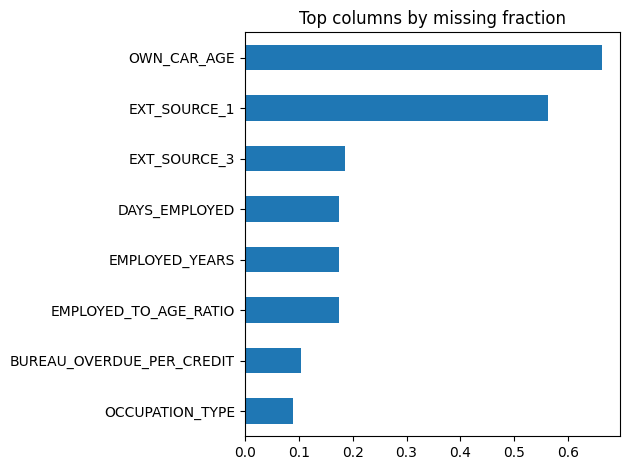

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"{len(missing)} columns have missing values.")
missing.head(15).plot(kind="barh", title="Top columns by missing fraction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Feature categorization

In [5]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()
print(f"Numeric features ({len(numeric_cols)}):", numeric_cols)
print(f"\nCategorical features ({len(categorical_cols)}):", categorical_cols)

Numeric features (49): ['SK_ID_CURR', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'REGION_POPULATION_RELATIVE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'TARGET', 'BUREAU_CREDIT_COUNT', 'BUREAU_ACTIVE_COUNT', 'BUREAU_AMT_CREDIT_SUM_TOTAL', 'BUREAU_AMT_CREDIT_SUM_MEAN', 'BUREAU_AMT_OVERDUE_TOTAL', 'BUREAU_MAX_DAYS_OVERDUE', 'BUREAU_DAYS_CREDIT_MEAN', 'BUREAU_ACTIVE_RATIO', 'BUREAU_HAS_OVERDUE', 'AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_TO_AGE_RATIO', 'CREDIT_TO_INCOME_RATIO', 'ANNUITY_TO_INCOME_RATIO', 'CREDIT_TO_GOODS_RATIO', 'INCOME_PER_FAMILY_MEMBER', 'ANNUITY_TO_CREDIT_RATIO', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MAX', 'EXT_S

## 4. Business insight #1 -- Default rate by income type

**Insight:** income type is a strong, policy-actionable segmentation
variable for underwriting tiers.

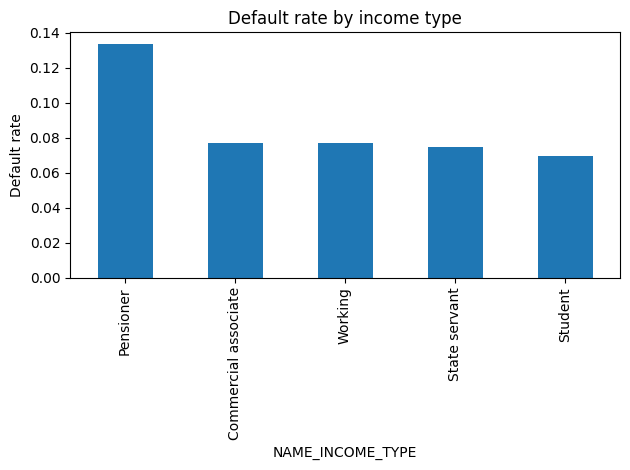

In [6]:
df.groupby("NAME_INCOME_TYPE")["TARGET"].mean().sort_values(ascending=False).plot(
    kind="bar", title="Default rate by income type"
)
plt.ylabel("Default rate")
plt.tight_layout()
plt.show()

## 5. Business insight #2 -- External bureau score vs default

**Insight:** EXT_SOURCE_* is the single most bankable signal in this
dataset -- defaulters concentrate heavily at low scores.

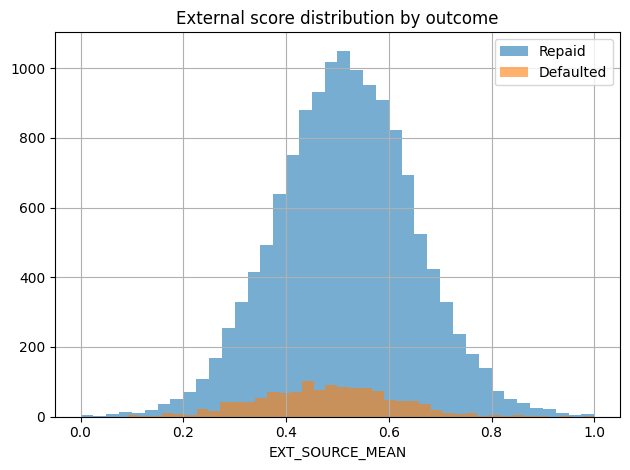

In [7]:
for target_val, label in [(0, "Repaid"), (1, "Defaulted")]:
    df.loc[df["TARGET"] == target_val, "EXT_SOURCE_MEAN"].hist(
        bins=40, alpha=0.6, label=label
    )
plt.legend()
plt.title("External score distribution by outcome")
plt.xlabel("EXT_SOURCE_MEAN")
plt.tight_layout()
plt.show()

## 6. Business insight #3 -- Credit-to-income ratio vs default

**Insight:** defaulters skew toward higher credit-to-income ratios --
supports an affordability cap in credit policy.

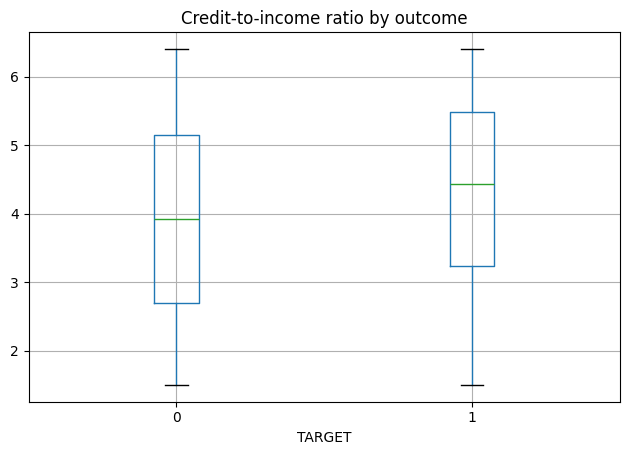

In [8]:
clip_q = df["CREDIT_TO_INCOME_RATIO"].quantile(0.98)
df_clip = df[df["CREDIT_TO_INCOME_RATIO"] < clip_q]
df_clip.boxplot(column="CREDIT_TO_INCOME_RATIO", by="TARGET")
plt.title("Credit-to-income ratio by outcome")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 7. Business insight #4 -- Age vs default

**Insight:** younger applicants default more often -- age (as a proxy
for credit history length and income stability) carries real signal.

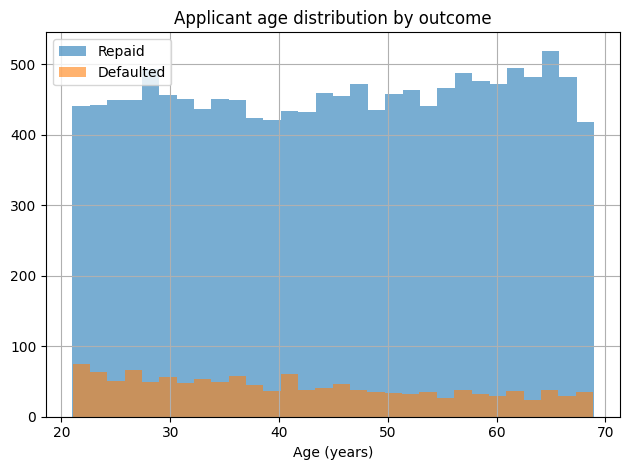

In [9]:
for target_val, label in [(0, "Repaid"), (1, "Defaulted")]:
    df.loc[df["TARGET"] == target_val, "AGE_YEARS"].hist(bins=30, alpha=0.6, label=label)
plt.legend()
plt.title("Applicant age distribution by outcome")
plt.xlabel("Age (years)")
plt.tight_layout()
plt.show()

## 8. Business insight #5 -- Prior bureau overdue history vs default

**Insight:** a history of overdue payments at OTHER lenders is one of
the strongest single predictors available -- exactly the cross-
institution signal a credit bureau feed exists to provide.

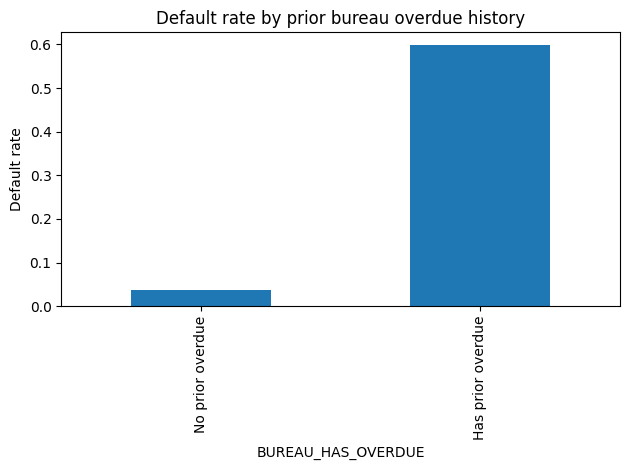

In [10]:
if "BUREAU_HAS_OVERDUE" in df.columns:
    df.groupby("BUREAU_HAS_OVERDUE")["TARGET"].mean().rename(
        index={0: "No prior overdue", 1: "Has prior overdue"}
    ).plot(kind="bar", title="Default rate by prior bureau overdue history")
    plt.ylabel("Default rate")
    plt.tight_layout()
    plt.show()
else:
    print("bureau.csv not loaded -- skip (see data/README.md to enable bureau features).")

## Summary of findings

1. Income type is a strong, actionable underwriting segmentation variable.
2. External bureau scores (EXT_SOURCE_1/2/3) are the dominant predictive
   signal -- confirmed again by SHAP global importance in the app.
3. Credit-to-income ratio separates repayers from defaulters and
   supports an affordability-based policy cap.
4. Age carries real signal, net of other factors -- must be used
   carefully alongside fair-lending review.
5. Prior bureau overdue history is one of the single strongest
   predictors -- it dominates the auto-derived business rules.

See `src/ml/train.py` for how these findings translate into the modeling
approach (LightGBM + cost-sensitive threshold), and the Streamlit app's
Explainability / Business Rules pages for how the trained model
operationalizes them.